### imported libraries + fixed random seeds

In [125]:
#Imports
import torch
from torchvision import datasets, transforms

#device selection
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

#reproducibility (same results for each run)
import random, numpy as np
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
print("Seed is set")

Using device: cpu
Seed is set


### loaded the EMNIST balanced dataset

In [126]:
# define transform (fix orientation and normalize)

transform = transforms.Compose([
    transforms.ToTensor(),  # convert to tensor [0,1]
    transforms.Normalize((0.5,), (0.5,)), # scale to [-1,1]

    # EMNIST images need two corrections:
    # 1. Rotate 90° counterclockwise (k=-1 means CCW, same as 270° CW)
    # 2. Flip horizontally to undo the mirror
    transforms.Lambda(lambda x: torch.rot90(x, k=-1, dims=[1, 2])),  # rotate 90° CCW
    transforms.Lambda(lambda x: torch.flip(x, [2]))                   # flip horizontally
])

#load datasets: EMNIST Balanced = digits + letters

train_dataset = datasets.EMNIST(
    root="data_emnist",
    split="balanced",     # digits + letters (47 classes total)
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.EMNIST(
    root="data_emnist",
    split="balanced",
    train=False,
    transform=transform,
    download=True
)

# --- dataloaders ---
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))
print("Number of classes:", len(train_dataset.classes))

Train samples: 112800
Test samples: 18800
Number of classes: 47


### Visualizing some EMNIST samples

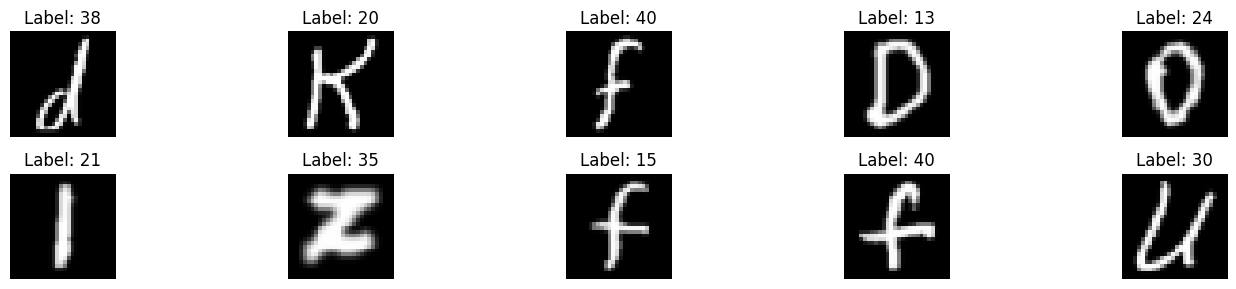

Sample labels: [38, 20, 40, 13, 24, 21, 35, 15, 40, 30]


In [127]:
import matplotlib.pyplot as plt
import numpy as np

#get a batch of data
images, labels = next(iter(train_loader))

#convert to numpy for plotting
images = images.numpy()

#number of images to show
num_images = 10

plt.figure(figsize=(15,3))
for i in range(num_images):
    plt.subplot(2,5, i+1)
    plt.imshow(np.squeeze(images[i]), cmap="gray")
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

print("Sample labels:", labels[:10].tolist())

### Retrieve Official EMNIST Class Labels

In [128]:
emnist_classes = train_dataset.classes      # a list of 47 strings in the right order
print("Total classes:", len(emnist_classes))
print(len(emnist_classes), emnist_classes[:])



Total classes: 47
47 ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']


### Visualizing EMNIST samples with real labels

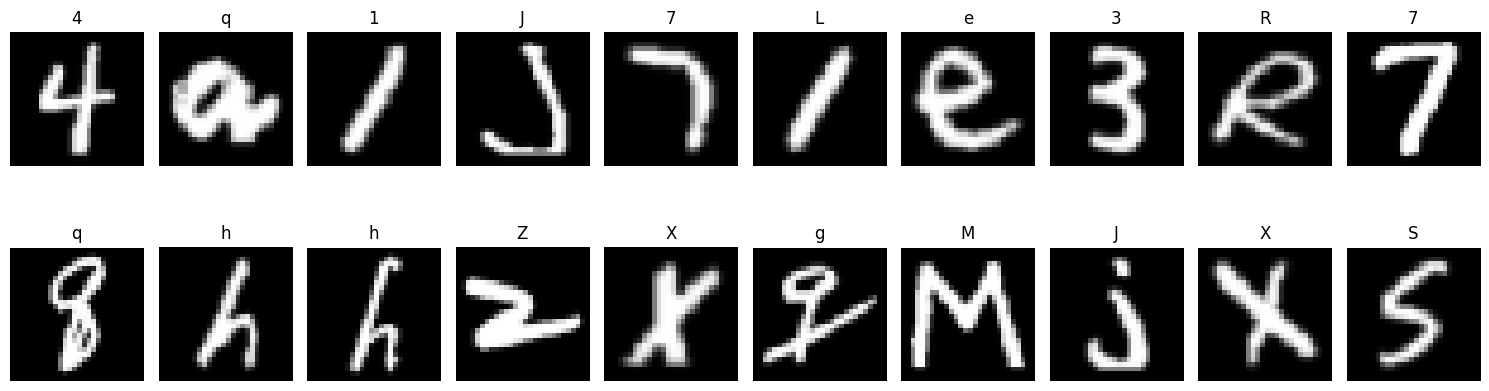

In [129]:
# get a random batch
images, labels = next(iter(train_loader))
images, labels = images.numpy(), labels.numpy()

# number of images to show
num_images = 20
indices = random.sample(range(len(images)), num_images)

plt.figure(figsize=(15, 5))
for i, idx in enumerate(indices):
    plt.subplot(2, 10, i + 1)
    plt.imshow(np.squeeze(images[idx]), cmap="gray")
    plt.title(emnist_classes[labels[idx]])  # use our mapping
    plt.axis("off")

plt.tight_layout()
plt.show()

### Defining CNN

In [130]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        #  Convolution layers 
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)
        
        # Fully connected layers 
        # after two conv + pool layers the feature map is 64 × 5 × 5
        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 47)   # 47 classes (digits + letters)

    def forward(self, x):
        # Conv -> ReLU -> Pool
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        # Conv -> ReLU -> Pool
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        # Flatten
        x = x.view(x.size(0), -1)
        # Fully connected -> ReLU
        x = F.relu(self.fc1(x))
        # Output layer (raw scores)
        x = self.fc2(x)
        return x


### Initializing the model, loss function, and optimizer

In [131]:
# initialize model 
model = Net().to(device)

# loss function
criterion = nn.CrossEntropyLoss()

#optimizer 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Model ready on device:", device)


Model ready on device: cpu


### Training loop 


In [132]:
num_epochs = 5 

for epoch in range(num_epochs):
    model.train()             # set model to training mode
    running_loss = 0.0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        # 1. Zero gradients
        optimizer.zero_grad()

        # 2. Forward pass
        outputs = model(images)

        # 3. Compute loss
        loss = criterion(outputs, labels)

        # 4. Backward pass
        loss.backward()

        # 5. Update weights
        optimizer.step()

        running_loss += loss.item()

        if (batch_idx + 1) % 200 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{batch_idx+1}/{len(train_loader)}], Loss: {loss.item():.4f}")

    epoch_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}] completed — Avg Loss: {epoch_loss:.4f}\n")


Epoch [1/5], Step [200/1763], Loss: 0.7422
Epoch [1/5], Step [400/1763], Loss: 0.6123
Epoch [1/5], Step [600/1763], Loss: 0.6227
Epoch [1/5], Step [800/1763], Loss: 0.4155
Epoch [1/5], Step [1000/1763], Loss: 0.5038
Epoch [1/5], Step [1200/1763], Loss: 0.4181
Epoch [1/5], Step [1400/1763], Loss: 0.4999
Epoch [1/5], Step [1600/1763], Loss: 0.4190
Epoch [1/5] completed — Avg Loss: 0.6925

Epoch [2/5], Step [200/1763], Loss: 0.5103
Epoch [2/5], Step [400/1763], Loss: 0.2988
Epoch [2/5], Step [600/1763], Loss: 0.3478
Epoch [2/5], Step [800/1763], Loss: 0.3901
Epoch [2/5], Step [1000/1763], Loss: 0.3826
Epoch [2/5], Step [1200/1763], Loss: 0.2368
Epoch [2/5], Step [1400/1763], Loss: 0.4070
Epoch [2/5], Step [1600/1763], Loss: 0.3282
Epoch [2/5] completed — Avg Loss: 0.4005

Epoch [3/5], Step [200/1763], Loss: 0.3350
Epoch [3/5], Step [400/1763], Loss: 0.3110
Epoch [3/5], Step [600/1763], Loss: 0.3931
Epoch [3/5], Step [800/1763], Loss: 0.3523
Epoch [3/5], Step [1000/1763], Loss: 0.3122
Epoc

### evaluation


Overall Test Accuracy: 87.13%



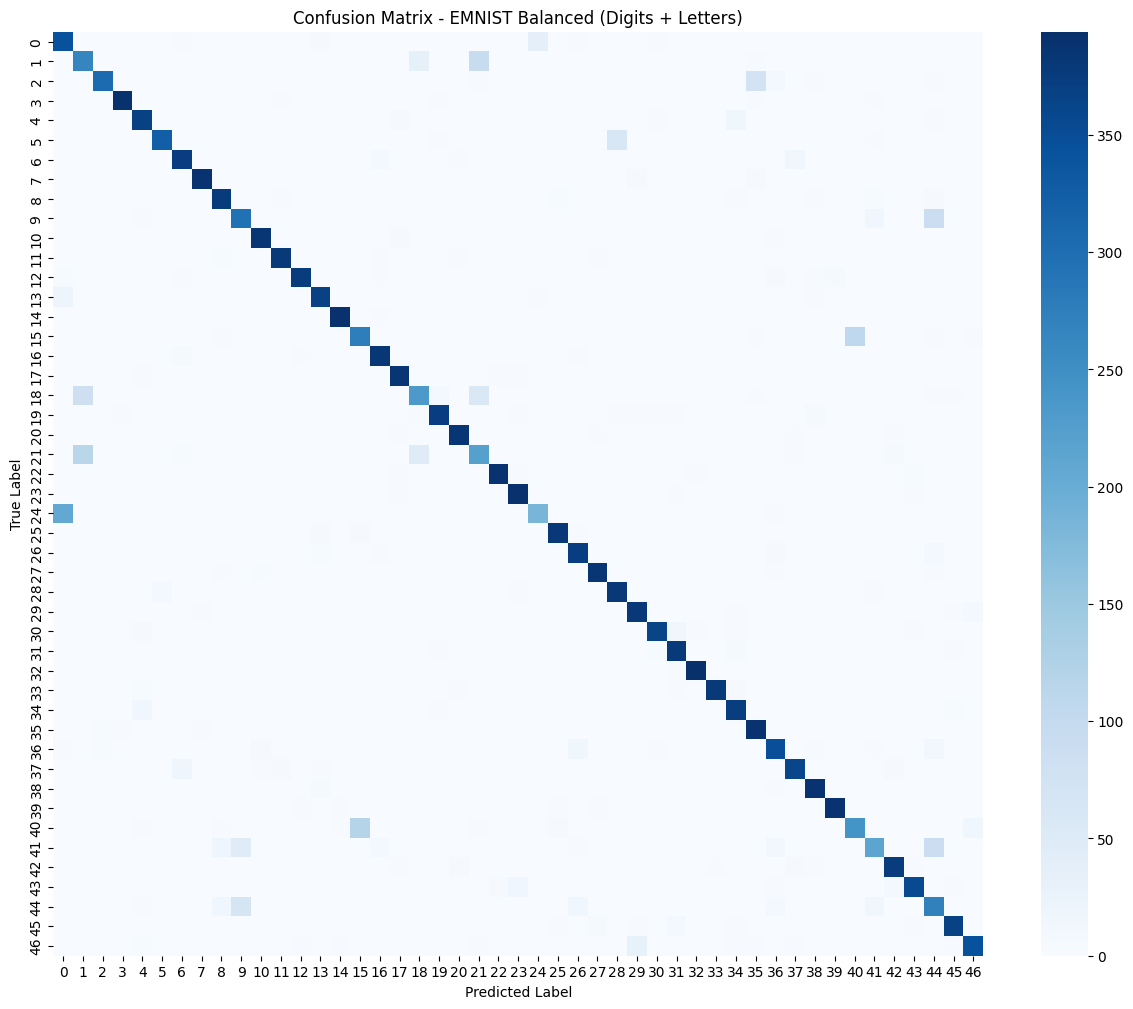

Classification Report (Precision, Recall, F1-score):

              precision    recall  f1-score   support

           0      0.592     0.860     0.701       400
           1      0.569     0.662     0.612       400
           2      0.968     0.762     0.853       400
           3      0.985     0.975     0.980       400
           4      0.900     0.922     0.911       400
           5      0.967     0.807     0.880       400
           6      0.907     0.930     0.919       400
           7      0.977     0.970     0.974       400
           8      0.885     0.943     0.913       400
           9      0.709     0.738     0.723       400
           A      0.955     0.963     0.959       400
           B      0.957     0.950     0.954       400
           C      0.962     0.938     0.949       400
           D      0.927     0.917     0.922       400
           E      0.978     0.978     0.978       400
           F      0.684     0.693     0.688       400
           G      0.912    

In [134]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Accuracy
accuracy = 100 * np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Overall Test Accuracy: {accuracy:.2f}%\n")

# Confusion Matrix 
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=False, cmap="Blues", fmt="d")
plt.title("Confusion Matrix - EMNIST Balanced (Digits + Letters)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Classification Report 
print("Classification Report (Precision, Recall, F1-score):\n")
print(classification_report(all_labels, all_preds, target_names=emnist_classes, digits=3))
